In [4]:
import pandas as pd
df = pd.read_csv("cleaned_superstore.csv")

In [5]:
unique_customers = df["Customer ID"].nunique()
print("Unique Customers:", unique_customers)

Unique Customers: 793


In [6]:
customer_sales = (df.groupby(["Customer ID", "Customer Name"])["Sales"].sum().sort_values(ascending=False))
customer_sales.head(10)

Customer ID  Customer Name     
SM-20320     Sean Miller           25043.050
TC-20980     Tamara Chand          19052.218
RB-19360     Raymond Buch          15117.339
TA-21385     Tom Ashbrook          14595.620
AB-10105     Adrian Barton         14473.571
KL-16645     Ken Lonsdale          14175.229
SC-20095     Sanjit Chand          14142.334
HL-15040     Hunter Lopez          12873.298
SE-20110     Sanjit Engle          12209.438
CC-12370     Christopher Conant    12129.072
Name: Sales, dtype: float64

In [7]:
customer_orders = (df.groupby("Customer ID")["Order ID"].nunique().sort_values(ascending=False))
customer_orders.head(10)

Customer ID
EP-13915    17
ZC-21910    13
CK-12205    13
JE-15745    13
PG-18820    13
SH-19975    12
RP-19390    12
SJ-20125    12
BP-11095    12
NS-18640    12
Name: Order ID, dtype: int64

In [8]:
customer_average = (df.groupby("Customer ID")["Sales"].mean().sort_values(ascending=False))
customer_average.head(10)

Customer ID
MW-18235    1751.292000
SM-20320    1669.536667
TC-20980    1587.684833
GT-14635    1558.535333
TA-21385    1459.562000
HL-15040    1170.299818
BS-11365    1166.850333
CC-12370    1102.642909
SH-20635    1048.196000
CM-12385     895.402000
Name: Sales, dtype: float64

In [9]:
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Average_Sales=("Sales", "mean"),
    Number_of_Orders=("Order ID", "nunique"),
    Number_of_Customers=("Customer ID", "nunique")
)
segment_analysis

,Total_Sales,Average_Sales,Number_of_Orders,Number_of_Customers
Segment,,,,
Consumer,1.148061e+06,225.065777,2537,409
Corporate,6.884941e+05,233.150720,1491,236
Home Office,4.249822e+05,243.403309,894,148


In [10]:
state_sales = (df.groupby("State")["Sales"].sum().sort_values(ascending=False))
state_sales.head(10)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

In [11]:
customer_total = df.groupby("Customer ID")["Sales"].sum()
threshold = customer_total.quantile(0.90)
high_value_customers = customer_total[customer_total >= threshold]
print("High-value customer threshold:", threshold)
print("Number of high-value customers:", len(high_value_customers))

High-value customer threshold: 5964.871200000005
Number of high-value customers: 80


In [12]:
customer_category = pd.pivot_table(df,values="Sales",index="Segment",columns="Category",aggfunc="sum")
customer_category

Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,387696.2580,359352.608,401011.665
Corporate,220321.7018,224130.536,244041.837
Home Office,120640.6159,121939.190,182402.371


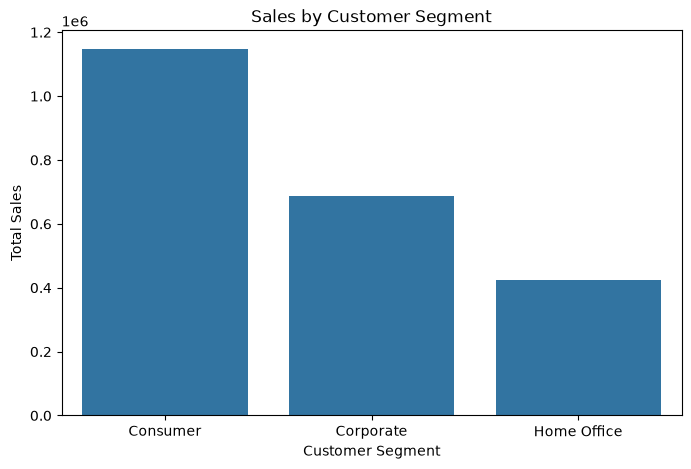

In [13]:
#Bar Plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = pd.read_csv("cleaned_superstore.csv")
plt.figure(figsize=(8, 5))
sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis["Total_Sales"]
)
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()